In [1]:
!pip install opencv-python-headless matplotlib numpy -q

In [2]:
from google.colab import files
from IPython.display import Image, display

import numpy as np
import cv2
import matplotlib.pyplot as plt
import io
from PIL import Image as PILImage
import warnings
warnings.filterwarnings('ignore')

In [3]:
class DeuteranopiaSimulator:
    """Color Blindness Simulator（Deuteranopia）"""

    def __init__(self):
        self.rgb_to_lms = np.array([
            [0.4002, 0.7076, -0.0808],
            [-0.2263, 1.1653, 0.0457],
            [0.0, 0.0, 0.9182]
        ], dtype=np.float32)

        self.lms_to_rgb = np.linalg.inv(self.rgb_to_lms)

        self.vischeck_deuteranopia = np.array([
            [0.2920, 0.7050, -0.0000],
            [0.2920, 0.7050, -0.0000],
            [-0.0210, 0.0300, 1.0000]
        ], dtype=np.float32)

        self.full_transform_matrix = self._compute_full_matrix()

    def _compute_full_matrix(self):
        return self.lms_to_rgb @ self.vischeck_deuteranopia @ self.rgb_to_lms

    def simulate(self, image, severity=1.0):
        """Simulate green color blindness vision"""
        if len(image.shape) == 2:
            img_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        else:
            img_rgb = image.copy()

        img_float = img_rgb.astype(np.float32) / 255.0
        h, w = img_float.shape[:2]
        pixels = img_float.reshape(-1, 3)

        lms = pixels @ self.rgb_to_lms.T
        lms_simulated = lms @ self.vischeck_deuteranopia.T
        lms_blended = (1 - severity) * lms + severity * lms_simulated
        rgb_simulated = lms_blended @ self.lms_to_rgb.T
        rgb_simulated = np.clip(rgb_simulated, 0.0, 1.0)

        return (rgb_simulated.reshape(h, w, 3) * 255).astype(np.uint8)

    def get_difference_map(self, original, simulated, signed=True):
        """Calculate difference map"""
        orig_float = original.astype(np.float32) / 255.0
        sim_float = simulated.astype(np.float32) / 255.0
        diff = sim_float - orig_float
        if not signed:
            diff = np.abs(diff)
        return np.clip(diff, -1.0 if signed else 0.0, 1.0)

    @staticmethod
    def nonlinear_amplify(diff_map, gamma=0.3, signed=True):
        """
        Nonlinear amplification of the difference image

        Args:
            diff_map: Input difference map, range [-1, 1] or [0, 1]
            gamma: Gamma value (<1 amplifies small values, >1 compresses large values)
            signed: Is it a signed difference map?

        Returns:
            Magnified difference image
        """
        if signed:
            # Handle the positive and negative parts separately
            pos_part = np.maximum(diff_map, 0)
            neg_part = np.minimum(diff_map, 0)

            # Apply gamma transformation
            pos_amplified = np.power(pos_part, gamma)
            neg_amplified = -np.power(-neg_part, gamma)

            return pos_amplified + neg_amplified
        else:
            # Absolute difference image directly applied with gamma
            return np.power(diff_map, gamma)

    def visualize_diff(self, diff_map, signed=True):
        """Visualized difference map"""
        if signed:
            vis = ((diff_map + 1) / 2 * 255).astype(np.uint8)
        else:
            vis = (diff_map * 255).astype(np.uint8)
        return vis

In [4]:
class DarkGlassesSimulator:
    """Sunglasses Simulator"""

    def __init__(self, brightness=0.6, saturation=1.3, glare_threshold=200, glare_suppression=0.3):
        self.brightness = brightness
        self.saturation = saturation
        self.glare_threshold = glare_threshold
        self.glare_suppression = glare_suppression

    def simulate(self, image):
        """Simulate sunglasses effect"""
        if len(image.shape) == 2:
            img_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        else:
            img_rgb = image.copy()

        img_float = img_rgb.astype(np.float32) / 255.0

        # Lower brightness
        img_bright = img_float * self.brightness

        # Increase saturation
        img_hsv = cv2.cvtColor(img_bright, cv2.COLOR_RGB2HSV)
        h, s, v = cv2.split(img_hsv)
        s = np.clip(s * self.saturation, 0.0, 1.0)
        img_hsv = cv2.merge([h, s, v])
        img_saturated = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

        # Anti-glare
        luminance = 0.299 * img_float[:,:,0] + 0.587 * img_float[:,:,1] + 0.114 * img_float[:,:,2]
        glare_mask_2d = (luminance * 255 > self.glare_threshold).astype(np.float32)
        glare_mask_3d = np.expand_dims(glare_mask_2d, axis=-1)
        glare_mask_3d = np.repeat(glare_mask_3d, 3, axis=-1)

        result = img_saturated * (1 - glare_mask_3d * self.glare_suppression * 0.5)

        img_gray = np.stack([luminance, luminance, luminance], axis=-1)
        result = result * (1 - glare_mask_3d * self.glare_suppression) + \
                 img_gray * (glare_mask_3d * self.glare_suppression)

        result = np.clip(result, 0.0, 1.0)
        return (result * 255).astype(np.uint8)

    def get_difference_map(self, original, simulated, signed=True):
        """Calculate difference map"""
        orig_float = original.astype(np.float32) / 255.0
        sim_float = simulated.astype(np.float32) / 255.0
        diff = sim_float - orig_float
        if not signed:
            diff = np.abs(diff)
        return np.clip(diff, -1.0 if signed else 0.0, 1.0)

In [5]:
class DifferenceMapProcessor:
    """Difference Map Processor: Supports nonlinear amplification and grayscale difference mapping"""

    @staticmethod
    def nonlinear_amplify(diff_map, gamma=0.5, signed=True):
        """
        Nonlinear amplification of the difference image

        Args:
            diff_map: Input difference map, range [-1, 1] or [0, 1]
            gamma: Gamma value (<1 amplifies small values, >1 compresses large values)
            signed: Whether the difference map is signed
        Returns:
            Magnified difference image
        """
        if signed:
            # Handle the positive and negative parts separately
            pos_part = np.maximum(diff_map, 0)
            neg_part = np.minimum(diff_map, 0)

            # Apply gamma transformation
            pos_amplified = np.power(pos_part, gamma)
            neg_amplified = -np.power(-neg_part, gamma)

            return pos_amplified + neg_amplified
        else:
            # Absolute difference image directly applied with gamma
            return np.power(diff_map, gamma)

    @staticmethod
    def get_grayscale_difference(original, signed=True, normalize=True):
        """
        Compute the difference image between the original image and the grayscale image

        Grayscale images provide pure structural information (without color), while difference images highlight regions with rich colors.

        Args:
            original: original RGB image, range [0, 255]
            signed: whether to return a signed difference map
            normalize: whether to normalize
        Returns:
            Grayscale difference map
        """
        orig_float = original.astype(np.float32) / 255.0

        # Calculate grayscale image
        gray = 0.299 * orig_float[:,:,0] + 0.587 * orig_float[:,:,1] + 0.114 * orig_float[:,:,2]
        gray_3ch = np.stack([gray, gray, gray], axis=-1)

        # variance in calculation
        diff = orig_float - gray_3ch

        if not signed:
            diff = np.abs(diff)

        if normalize:
            if signed:
                diff = np.clip(diff, -1.0, 1.0)
            else:
                diff = np.clip(diff, 0.0, 1.0)

        return diff

In [42]:
# Upload image
print("Please upload an image...")
uploaded = files.upload()

# Get the uploaded filename
image_path = list(uploaded.keys())[0]
print(f"Upload successful: {image_path}")

# Read image
image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
print(f"Image dimensions: {image.shape}")

Please upload an image...


Saving cat.jpg to cat.jpg
Upload successful: cat.jpg
Image dimensions: (3024, 4032, 3)


In [43]:
# Initialization
cb_sim = DeuteranopiaSimulator()
dg_sim = DarkGlassesSimulator()
diff_processor = DifferenceMapProcessor()

# 1. Generate colorblindness and difference images
colorblind_img = cb_sim.simulate(image, severity=1.0)
diff_cb = cb_sim.get_difference_map(image, colorblind_img, signed=True)

# 1b. Apply nonlinear amplification to the colorblindness difference image (try different gamma values)
gamma_values = [0.3, 0.5, 0.7]
diff_cb_amplified = {}
for gamma in gamma_values:
    diff_cb_amplified[gamma] = diff_processor.nonlinear_amplify(diff_cb, gamma=gamma, signed=True)

# 2. Generate sunglasses and difference images
glasses_img = dg_sim.simulate(image)
diff_dg = dg_sim.get_difference_map(image, glasses_img, signed=True)

# 3. Generate grayscale difference image
diff_gray = diff_processor.get_grayscale_difference(image, signed=True, normalize=True)

# 4. Visualization version
diff_cb_vis = cb_sim.visualize_diff(diff_cb, signed=True)
diff_dg_vis = cb_sim.visualize_diff(diff_dg, signed=True)
diff_gray_vis = cb_sim.visualize_diff(diff_gray, signed=True)

# Visualized after nonlinear amplification
diff_cb_amp_vis = {}
for gamma in gamma_values:
    diff_cb_amp_vis[gamma] = cb_sim.visualize_diff(diff_cb_amplified[gamma], signed=True)

print("Generation complete!")

Generation complete!


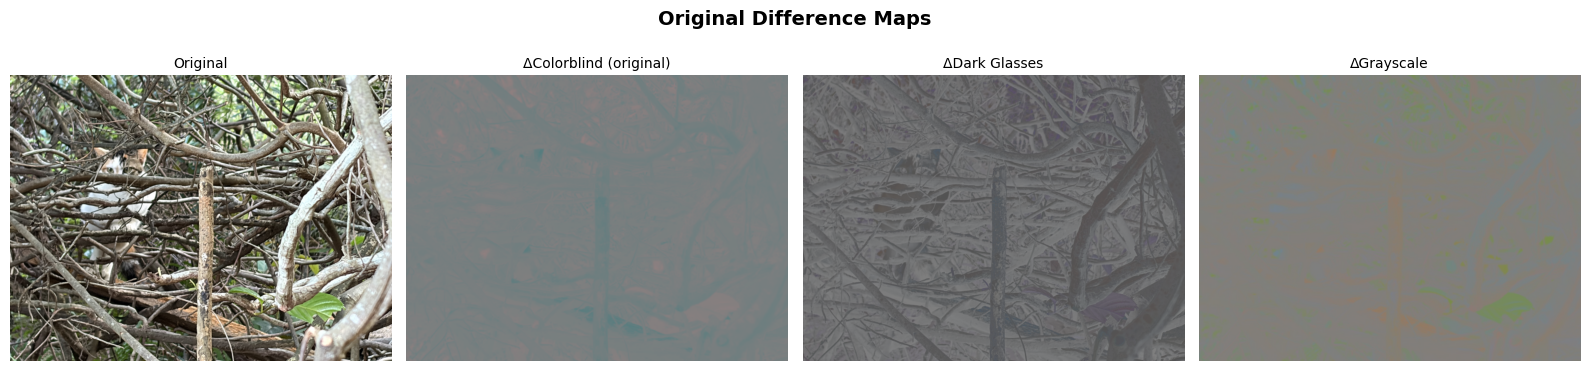

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original difference map
axes[0].imshow(image)
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

axes[1].imshow(diff_cb_vis)
axes[1].set_title('ΔColorblind (original)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(diff_dg_vis)
axes[2].set_title('ΔDark Glasses', fontsize=10)
axes[2].axis('off')

axes[3].imshow(diff_gray_vis)
axes[3].set_title('ΔGrayscale', fontsize=10)
axes[3].axis('off')

plt.suptitle('Original Difference Maps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

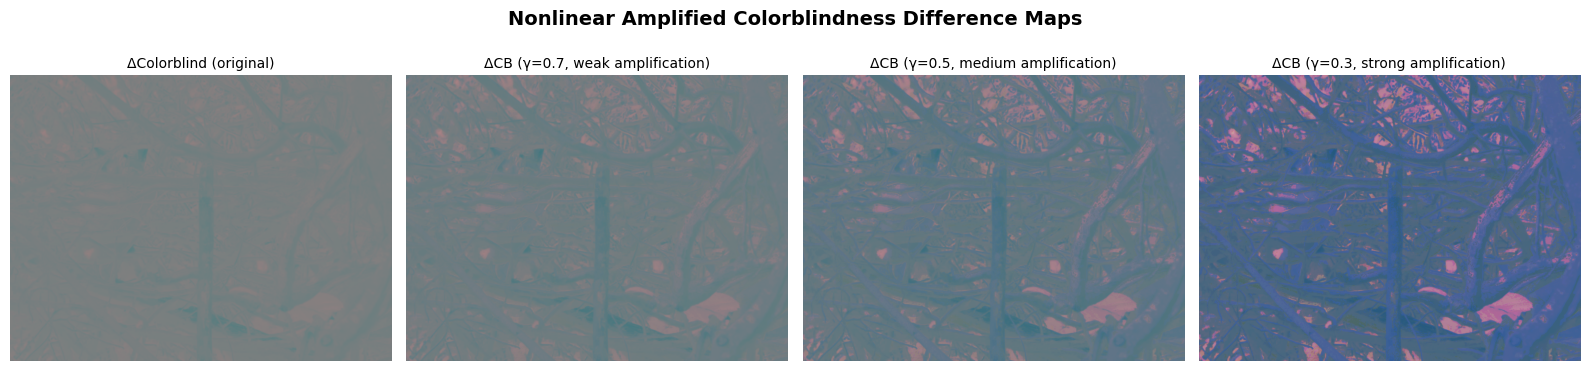



====================Statistics Comparison====================
Nonlinear Amplification Effect Comparison (ΔCB)

Original difference map:
  mean: -0.0183
  std: 0.0332
  non-zero: 32.1%

γ=0.7 (weak amplification)
  mean: -0.0439
  std: 0.0694
  non-zero: 79.2%

γ=0.5 (medium amplification)
  mean: -0.0819
  std: 0.1195
  non-zero: 79.2%

γ=0.3 (strong amplification)
  mean: -0.1589
  std: 0.2244
  non-zero: 79.2%


In [45]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Colorblindness difference map after nonlinear amplification
axes[0].imshow(diff_cb_vis)
axes[0].set_title('ΔColorblind (original)', fontsize=10)
axes[0].axis('off')

axes[1].imshow(diff_cb_amp_vis[0.7])
axes[1].set_title('ΔCB (γ=0.7, weak amplification)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(diff_cb_amp_vis[0.5])
axes[2].set_title('ΔCB (γ=0.5, medium amplification)', fontsize=10)
axes[2].axis('off')

axes[3].imshow(diff_cb_amp_vis[0.3])
axes[3].set_title('ΔCB (γ=0.3, strong amplification)', fontsize=10)
axes[3].axis('off')

plt.suptitle('Nonlinear Amplified Colorblindness Difference Maps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n")
print("=" * 20 + 'Statistics Comparison' + "=" * 20)
print("Nonlinear Amplification Effect Comparison (ΔCB)")

print("\nOriginal difference map:")
print(f"  mean: {diff_cb.mean():.4f}")
print(f"  std: {diff_cb.std():.4f}")
print(f"  non-zero: {(np.abs(diff_cb) > 0.01).mean():.1%}")

print("\nγ=0.7 (weak amplification)")
print(f"  mean: {diff_cb_amplified[0.7].mean():.4f}")
print(f"  std: {diff_cb_amplified[0.7].std():.4f}")
print(f"  non-zero: {(np.abs(diff_cb_amplified[0.7]) > 0.01).mean():.1%}")

print("\nγ=0.5 (medium amplification)")
print(f"  mean: {diff_cb_amplified[0.5].mean():.4f}")
print(f"  std: {diff_cb_amplified[0.5].std():.4f}")
print(f"  non-zero: {(np.abs(diff_cb_amplified[0.5]) > 0.01).mean():.1%}")

print("\nγ=0.3 (strong amplification)")
print(f"  mean: {diff_cb_amplified[0.3].mean():.4f}")
print(f"  std: {diff_cb_amplified[0.3].std():.4f}")
print(f"  non-zero: {(np.abs(diff_cb_amplified[0.3]) > 0.01).mean():.1%}")
print("=" * 62)

In [46]:
print("=" * 70)
print("Summary of Differential Plot Statistics")
print("=" * 70)

print(f"\nΔColorblind Difference Map - Original")
print(f"  - Range: [{diff_cb.min():.4f}, {diff_cb.max():.4f}]")
print(f"  - Mean: {diff_cb.mean():.4f}")
print(f"  - Standard Deviation: {diff_cb.std():.4f}")
print(f"  - Non-zero Proportion: {(np.abs(diff_cb) > 0.01).mean():.2%}")

print(f"\nΔColorblind Difference Map - Nonlinear Amplification γ=0.3")
print(f"  - Range: [{diff_cb_amplified[0.3].min():.4f}, {diff_cb_amplified[0.3].max():.4f}]")
print(f"  - Mean: {diff_cb_amplified[0.3].mean():.4f}")
print(f"  - Standard Deviation: {diff_cb_amplified[0.3].std():.4f}")
print(f"  - Non-zero Proportion: {(np.abs(diff_cb_amplified[0.3]) > 0.01).mean():.2%}")

print(f"\nΔSunglasses Difference Map")
print(f"  - Range: [{diff_dg.min():.4f}, {diff_dg.max():.4f}]")
print(f"  - Mean: {diff_dg.mean():.4f}")
print(f"  - Standard Deviation: {diff_dg.std():.4f}")
print(f"  - Non-zero Ratio: {(np.abs(diff_dg) > 0.01).mean():.2%}")

print(f"\nΔGrayscale Difference Map")
print(f"  - Range: [{diff_gray.min():.4f}, {diff_gray.max():.4f}]")
print(f"  - Mean: {diff_gray.mean():.4f}")
print(f"  - Standard Deviation: {diff_gray.std():.4f}")
print(f"  - Non-zero Ratio: {(np.abs(diff_gray) > 0.01).mean():.2%}")
print("=" * 70)

Summary of Differential Plot Statistics

ΔColorblind Difference Map - Original
  - Range: [-0.3373, 0.2000]
  - Mean: -0.0183
  - Standard Deviation: 0.0332
  - Non-zero Proportion: 32.08%

ΔColorblind Difference Map - Nonlinear Amplification γ=0.3
  - Range: [-0.7218, 0.6170]
  - Mean: -0.1589
  - Standard Deviation: 0.2244
  - Non-zero Proportion: 79.18%

ΔSunglasses Difference Map
  - Range: [-0.3961, 0.0000]
  - Mean: -0.1802
  - Standard Deviation: 0.0883
  - Non-zero Ratio: 99.66%

ΔGrayscale Difference Map
  - Range: [-0.4442, 0.1891]
  - Mean: -0.0113
  - Standard Deviation: 0.0407
  - Non-zero Ratio: 66.23%


In [47]:
# Scheme 1: Original Image + ΔCB (Original) + ΔDG
tri_stream_1 = np.concatenate([
    image / 255.0,
    diff_cb,
    diff_dg
], axis=-1)

# Scheme 2: Original image + ΔCB (amplified γ=0.5) + ΔDG
tri_stream_2 = np.concatenate([
    image / 255.0,
    diff_cb_amplified[0.5],
    diff_dg
], axis=-1)

# Scheme 3: Original Image + ΔCB (amplified γ=0.5) + ΔGrayscale
tri_stream_3 = np.concatenate([
    image / 255.0,
    diff_cb_amplified[0.5],
    diff_gray
], axis=-1)

# Scheme 4: Original Image + ΔDG + ΔGrayscale
tri_stream_4 = np.concatenate([
    image / 255.0,
    diff_dg,
    diff_gray
], axis=-1)

# Calculate the information entropy of each scheme (a measure of information content)
def calc_entropy(tensor):
    """Calculate information entropy"""
    hist, _ = np.histogram(tensor.flatten(), bins=50, range=(-1, 1))
    hist = hist / (hist.sum() + 1e-6)
    entropy = -np.sum(hist * np.log2(hist + 1e-6))
    return entropy


print("=" * 70)
print("Comparison of Third-Tier Input Methods")
print("=" * 70)
print(f"\nScheme 1 (Original + ΔCB original + ΔDG): shape={tri_stream_1.shape}")
print(f"Scheme 2 (Original + ΔCB scaled γ=0.5 + ΔDG): shape={tri_stream_2.shape}")
print(f"Scheme 3 (Original + ΔCB scaled γ=0.5 + ΔGrayscale): shape={tri_stream_3.shape}")
print(f"Scheme 4 (Original + ΔDG + ΔGrayscale): shape={tri_stream_4.shape}")
print("-" * 70)
print(f"\nInformation entropy (information content) of each scheme:")
print(f"  Scheme 1: {calc_entropy(tri_stream_1):.2f} bits")
print(f"  Scheme 2: {calc_entropy(tri_stream_2):.2f} bits")
print(f"  Scheme 3: {calc_entropy(tri_stream_3):.2f} bits")
print(f"  Scheme 4: {calc_entropy(tri_stream_4):.2f} bits")
print("=" * 70)

Comparison of Third-Tier Input Methods

Scheme 1 (Original + ΔCB original + ΔDG): shape=(3024, 4032, 9)
Scheme 2 (Original + ΔCB scaled γ=0.5 + ΔDG): shape=(3024, 4032, 9)
Scheme 3 (Original + ΔCB scaled γ=0.5 + ΔGrayscale): shape=(3024, 4032, 9)
Scheme 4 (Original + ΔDG + ΔGrayscale): shape=(3024, 4032, 9)
----------------------------------------------------------------------

Information entropy (information content) of each scheme:
  Scheme 1: 4.46 bits
  Scheme 2: 4.62 bits
  Scheme 3: 4.31 bits
  Scheme 4: 4.51 bits
